# <h1 style="color: yellow;">Genetic Algorithm Model (second alternative model)</h1>

In [ ]:
#Notes:
    #GA -> Genetic Algorithm
    #Can we improve the model by automatically finding the best subset of variables?
    #However, it is important to note that to use this model, we need to combine it with a linear regression model, since the Genetic Algorithm (GA) model will return the best combination of variables
    #This way, we can evaluate whether the GA is truly able to find a configuration that improves upon our baseline

## Libraries

In [ ]:
#Call libraries
import numpy as np
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Transformers class 
import sys
sys.path.append("../")
from src.preprocessing import FeatureSelector

## Functions

In [ ]:
#Function that will select which factors allow the model to generalize better to data not used during training
def fitness_function(solution):
    '''
        The lower the RMSE, the better the solution.
        Using the cross-validation method, we will obtain a mean squared error for 5-fold cross-validation.
    '''

    selected_features = solution == 1

    #Avoid solutions with no selected features
    if selected_features.sum() == 0:
        return float("inf")

    X_selected = X_train_processed[:, selected_features]

    model = LinearRegression()

    scores = cross_val_score(
        model,
        X_selected,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    #Now the GA seeks a solution that performs well outside the training sample, rather than simply a solution that memorizes X_train
    return -scores.mean()

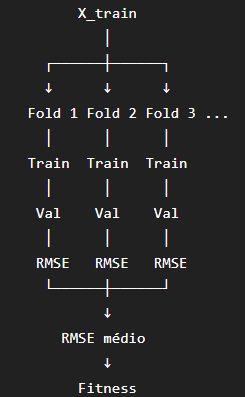

In [ ]:
#Selection
#Function to select the best individual that will win the comparison contest
def tournament_selection(population, fitness_scores):

    ''' We pick two individuals at random and let the best one win. '''
    
    idx1, idx2 = np.random.choice(
        len(population),
        size=2,
        replace=False
    )

    if fitness_scores[idx1] < fitness_scores[idx2]:
        return population[idx1]
    else:
        return population[idx2]

In [ ]:
#Crossover
#Function to concatenate the algorithms of two individuals at a random crossover point, generating an offspring with the genetic characteristics of both
def crossover(parent1, parent2):
    '''Function to concatenate the algorithms of two individuals at a random crossover point, generating an offspring with the genetic characteristics of both. '''

    #The selection will be made by a draw
    point = np.random.randint(
        1,
        len(parent1)
    )

    child = np.concatenate([
        parent1[:point],
        parent2[point:]
    ])

    return child

In [ ]:
#Mutation
#Function that randomly alters a child's genes based on a probability rate
def mutation(child, mutation_rate):
    ''' Function that randomly alters a child's genes based on a probability rate. '''

    for i in range(len(child)):

        if np.random.rand() < mutation_rate:
            child[i] = 1 - child[i]

    return child

## Training and tests variables import

In [ ]:
#Import training and test variables
import sys
sys.path.append("../")

from src.training_test_variables import (
    X,
    y,
    X_train,
    X_test,
    y_train,
    y_test
)

## One-Hot encoding

In [ ]:
#Columns type identification
categorical_columns = X.select_dtypes(
    include=["object", "string"]
).columns.tolist() #-> 14

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist() #-> 6

#Create the categorical columns preprocessing (the combination of values will result in 34 new categorical columns)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ],
    remainder="passthrough" #The numeric columns will pass directly
)
#Notes:
    #The `handle_unknown="ignore"` setting is important. Imagine a category appearing in `X_test` that didn't exist in `X_train`

## Data transformation process (GA - initial step)

In [ ]:
#GA selecting the 40 features after preprocessing

#Data transformation process
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

#Features definition
feature_names = preprocessor.get_feature_names_out()

#We have 40 features now
print(feature_names)
print(X_train_processed.shape)
print(X_test_processed.shape)

['categorical__Parental_Involvement_high'
 'categorical__Parental_Involvement_low'
 'categorical__Parental_Involvement_medium'
 'categorical__Access_to_Resources_high'
 'categorical__Access_to_Resources_low'
 'categorical__Access_to_Resources_medium'
 'categorical__Extracurricular_Activities_no'
 'categorical__Extracurricular_Activities_yes'
 'categorical__Motivation_Level_high' 'categorical__Motivation_Level_low'
 'categorical__Motivation_Level_medium' 'categorical__Internet_Access_no'
 'categorical__Internet_Access_yes' 'categorical__Family_Income_high'
 'categorical__Family_Income_low' 'categorical__Family_Income_medium'
 'categorical__Teacher_Quality_high' 'categorical__Teacher_Quality_low'
 'categorical__Teacher_Quality_medium' 'categorical__School_Type_private'
 'categorical__School_Type_public' 'categorical__Peer_Influence_negative'
 'categorical__Peer_Influence_neutral'
 'categorical__Peer_Influence_positive'
 'categorical__Learning_Disabilities_no'
 'categorical__Learning_Disa

## Manual determination of the best solution (GA - addtional step)

In [ ]:
#First, we need to create an initial population
n_features = X_train_processed.shape[1]
population_size = 600 

#Notes:
    #Just an example based on a fraction of the original quantity (~6,000)
    #The population size is directly related to the computational cost

population = np.random.randint(
    0,
    2,
    size=(population_size, n_features)
)

print(population.shape)

(600, 40)


In [ ]:
#Then, we evaluate each individual using our fitness_function
fitness_scores = []

for solution in population:
    fitness = fitness_function(solution)
    fitness_scores.append(fitness)

print(fitness_scores)

[np.float64(2.265859424028263), np.float64(2.9698815619620644), np.float64(3.1933383657855847), np.float64(2.841638842017841), np.float64(2.793041851092456), np.float64(3.6286977489160117), np.float64(2.169538456120887), np.float64(2.309601832801701), np.float64(3.2159999130486865), np.float64(3.230985653400675), np.float64(3.1189716083116354), np.float64(3.6910458183251564), np.float64(2.255790036037563), np.float64(3.3031956968788796), np.float64(2.1783092953898056), np.float64(3.6734389591342933), np.float64(2.301311788303167), np.float64(2.3087936491718706), np.float64(3.664766607448969), np.float64(3.7161927099867795), np.float64(2.3175662255193346), np.float64(2.2259981775605304), np.float64(3.6349962231072768), np.float64(2.130295219233489), np.float64(2.847825470662288), np.float64(3.0958073867896725), np.float64(2.895837114276718), np.float64(2.9958852507622327), np.float64(3.327437233797921), np.float64(2.348553712945044), np.float64(3.2422976585504286), np.float64(2.23525713

In [ ]:
#Since a lower RMSE is better, we can find the index of the best one
best_index = np.argmin(fitness_scores) 

#Returns the index (the position) of the smallest value in a NumPy array
print(best_index)

#Finally the best solution variables combination
best_solution = population[best_index]
print(best_solution)

507
[1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 0 0 1 1 0 0 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 0
 1 1 0]


In [ ]:
#Finally the best solution variables combination (names)
selected_features = feature_names[best_solution == 1]
print(selected_features)

#Notes:
   #This is still just the first generation
   #We identified the best individual from the initial population, but we haven't yet found the truly "genetic" part

['categorical__Parental_Involvement_high'
 'categorical__Parental_Involvement_low'
 'categorical__Parental_Involvement_medium'
 'categorical__Access_to_Resources_high'
 'categorical__Access_to_Resources_low'
 'categorical__Access_to_Resources_medium'
 'categorical__Extracurricular_Activities_no'
 'categorical__Motivation_Level_high' 'categorical__Motivation_Level_low'
 'categorical__Motivation_Level_medium' 'categorical__Internet_Access_no'
 'categorical__Family_Income_high' 'categorical__Teacher_Quality_low'
 'categorical__Teacher_Quality_medium'
 'categorical__Peer_Influence_negative'
 'categorical__Peer_Influence_neutral'
 'categorical__Learning_Disabilities_no'
 'categorical__Learning_Disabilities_yes'
 'categorical__Parental_Education_Level_college'
 'categorical__Parental_Education_Level_postgraduate'
 'categorical__Distance_from_Home_far'
 'categorical__Distance_from_Home_moderate' 'categorical__Gender_female'
 'categorical__Gender_male' 'remainder__Hours_Studied'
 'remainder__A

In [16]:
#Model training with the best solution found by the GA
X_train_ga = X_train_processed[:, best_solution == 1]
X_test_ga = X_test_processed[:, best_solution == 1]

model_ga = LinearRegression()

model_ga.fit(X_train_ga, y_train)

#Model predict
y_pred_ga = model_ga.predict(X_test_ga)

## Construction of the complete genetic algorithm model

### Genetic Algorithm Parameters

In [17]:
#Initial parameters
population_size = 600
n_generations = 30
mutation_rate = 0.05

#Notes:
    #population_size: 600 solutions per generation -> x 5 folds in fitness function = 3000 training runs
    #n_generations: the algorithm will evolve for 30 generations
    #mutation_rate: 5% chance of each gene undergoing mutation

### Create the initial population

In [18]:
n_features = X_train_processed.shape[1]

population = np.random.randint(
    0,
    2,
    size=(population_size, n_features)
)
display(population)

array([[0, 1, 1, ..., 0, 0, 1],
       [1, 1, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]], shape=(600, 40))

### Assess the population


In [19]:
fitness_scores = []

for solution in population:
    fitness = fitness_function(solution)
    fitness_scores.append(fitness)
    
print(fitness_scores)
#Attetion -> The lower the RMSE, the better the individual.

[np.float64(2.3687148495581827), np.float64(3.212764747203513), np.float64(3.7320161302728834), np.float64(2.446730572228637), np.float64(3.630282978607376), np.float64(2.780785200027779), np.float64(3.66811811224895), np.float64(3.251732465941901), np.float64(3.6741846346011444), np.float64(3.1990264212462223), np.float64(3.6259288128176514), np.float64(3.232938462300922), np.float64(2.8487735832115826), np.float64(3.71475836424617), np.float64(2.9294116336949227), np.float64(3.642049143016451), np.float64(3.6318249797270306), np.float64(2.855257444964703), np.float64(2.881939683525068), np.float64(2.899155461270401), np.float64(3.246978127480843), np.float64(3.6118011265043335), np.float64(3.2317344486473147), np.float64(2.838242995137967), np.float64(3.264373676180964), np.float64(3.0216096088370077), np.float64(2.91802147788474), np.float64(2.2572284926461115), np.float64(3.358022465778505), np.float64(2.18925465230179), np.float64(2.7031744437876286), np.float64(2.876768217582317)

### Finding the best individual (student)

In [20]:
best_index = np.argmin(fitness_scores)

best_solution = population[best_index]
best_fitness = fitness_scores[best_index]

print("Best fitness:", best_fitness)
print("Selected features:", best_solution.sum())

Best fitness: 2.0342570636786528
Selected features: 32


In [ ]:
#Notes:
    #This means that this solution used 24 of the 40 features

### Genetic assimilation - Selection x Crossover x Mutation

In [ ]:
#The best samples will generate a strong performance history based on the defined selection, crossover, and mutation functions and the initial parameters established as a standard example
new_population = []

for _ in range(population_size):

    parent1 = tournament_selection(
        population,
        fitness_scores
    )

    parent2 = tournament_selection(
        population,
        fitness_scores
    )

    child = crossover(parent1, parent2)

    child = mutation(
        child,
        mutation_rate
    )

    new_population.append(child)

population = np.array(new_population)

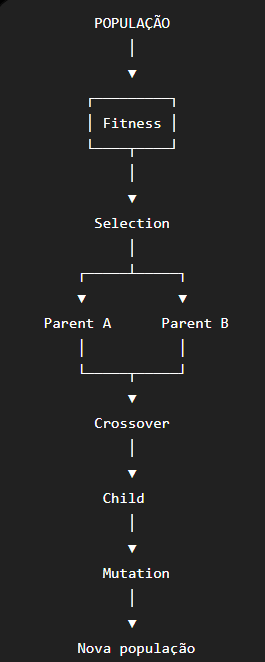

### Genetic loop - Compiling the entire algorithm in a loop

In [23]:
best_solution = None
best_fitness = float("inf")

for generation in range(n_generations):

    fitness_scores = [
        fitness_function(solution)
        for solution in population
    ]

    generation_best_index = np.argmin(
        fitness_scores
    )

    generation_best_fitness = fitness_scores[
        generation_best_index
    ]

    if generation_best_fitness < best_fitness:

        best_fitness = generation_best_fitness

        best_solution = population[
            generation_best_index
        ].copy()

    print(
        f"Generation {generation + 1}: "
        f"Best RMSE = {generation_best_fitness:.4f}"
    )

    new_population = []

    for _ in range(population_size):

        parent1 = tournament_selection(
            population,
            fitness_scores
        )

        parent2 = tournament_selection(
            population,
            fitness_scores
        )

        child = crossover(parent1, parent2)

        child = mutation(
            child,
            mutation_rate
        )

        new_population.append(child)

    population = np.array(new_population)

Generation 1: Best RMSE = 2.0542
Generation 2: Best RMSE = 2.0572
Generation 3: Best RMSE = 2.0474
Generation 4: Best RMSE = 2.0343
Generation 5: Best RMSE = 2.0438
Generation 6: Best RMSE = 2.0334
Generation 7: Best RMSE = 2.0336
Generation 8: Best RMSE = 2.0334
Generation 9: Best RMSE = 2.0334
Generation 10: Best RMSE = 2.0336
Generation 11: Best RMSE = 2.0334
Generation 12: Best RMSE = 2.0336
Generation 13: Best RMSE = 2.0334
Generation 14: Best RMSE = 2.0336
Generation 15: Best RMSE = 2.0334
Generation 16: Best RMSE = 2.0334
Generation 17: Best RMSE = 2.0336
Generation 18: Best RMSE = 2.0334
Generation 19: Best RMSE = 2.0334
Generation 20: Best RMSE = 2.0336
Generation 21: Best RMSE = 2.0332
Generation 22: Best RMSE = 2.0332
Generation 23: Best RMSE = 2.0334
Generation 24: Best RMSE = 2.0332
Generation 25: Best RMSE = 2.0341
Generation 26: Best RMSE = 2.0334
Generation 27: Best RMSE = 2.0334
Generation 28: Best RMSE = 2.0332
Generation 29: Best RMSE = 2.0334
Generation 30: Best RMS

In [ ]:
#Notes:
    #It can be observed that, starting from the 11th generation, the individuals have already reached the optimal configuration, rendering the subsequent ones redundant

### Best generation solution

In [25]:
#Finally the best solution variables combination
best_solution
best_fitness

np.float64(2.033206104147232)

In [26]:
#Best features selected for incorporation into a regression model
selected_features = feature_names[
    best_solution == 1
]

print(selected_features)
print("Number of features:", best_solution.sum())

['categorical__Parental_Involvement_low'
 'categorical__Parental_Involvement_medium'
 'categorical__Access_to_Resources_high'
 'categorical__Access_to_Resources_medium'
 'categorical__Extracurricular_Activities_no'
 'categorical__Extracurricular_Activities_yes'
 'categorical__Motivation_Level_high' 'categorical__Motivation_Level_low'
 'categorical__Motivation_Level_medium' 'categorical__Internet_Access_no'
 'categorical__Family_Income_low' 'categorical__Family_Income_medium'
 'categorical__Teacher_Quality_high' 'categorical__Teacher_Quality_low'
 'categorical__Peer_Influence_negative'
 'categorical__Peer_Influence_neutral'
 'categorical__Peer_Influence_positive'
 'categorical__Learning_Disabilities_no'
 'categorical__Parental_Education_Level_college'
 'categorical__Parental_Education_Level_high school'
 'categorical__Parental_Education_Level_postgraduate'
 'categorical__Distance_from_Home_moderate'
 'categorical__Distance_from_Home_near' 'remainder__Hours_Studied'
 'remainder__Attendan

## Create the linear regression model using the best features selected by the genetic algorithm model

In [27]:
#Select the features chosen by the Genetic Algorithm
selected_features = best_solution == 1

X_train_ga = X_train_processed[:, selected_features]
X_test_ga = X_test_processed[:, selected_features]

#Model training
model_ga = LinearRegression()

model_ga.fit(
    X_train_ga,
    y_train
)

#Model predict
y_pred_ga = model_ga.predict(
    X_test_ga
)

## Using loss functions to validate the model (metrics comparison)

In [28]:
#Mean absolute error
mae = mean_absolute_error(y_test, y_pred_ga)

#Mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ga))

#r2 error
r2 = r2_score(y_test, y_pred_ga)

#r2 error adjusted
n = len(y_test)
p = X_test_ga.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Results from model
print(f"MAE:  {mae:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"R²:   {r2:.5f}")
print(f"Adjusted R²: {adjusted_r2:.5f}")

MAE:  0.47701
RMSE: 2.03898
R²:   0.73441
Adjusted R²: 0.72845


In [29]:
#Features comparison
print("Baseline features:", X_train_processed.shape[1])
print("GA features:", X_train_ga.shape[1])

Baseline features: 40
GA features: 28


In [ ]:
#Notes:
   #The Genetic Algorithm reduced the number of features from 40 to 28 (30% reduction)
   #while maintaining similar predictive performance compared to the baseline Linear Regression model
   #This suggests that some features had limited impact on the model's predictive performance

In [31]:
#The selected features
print("\nSelected features:")
for feature in selected_features:
    print(feature)


Selected features:
False
True
True
True
False
True
True
True
True
True
True
True
False
False
True
True
True
True
False
False
False
True
True
True
True
False
True
True
True
False
True
True
False
False
True
True
False
True
True
True


## Saves the trained genetic algorithm model to a file

### Created pipeline to combine the preprocessor and the model

In [34]:
#Create a mask to receive the best solution variables combination
selected_mask = best_solution == 1

#Create a pipeline that combines the preprocessor, feature selector (from transformer class), and linear regression model
model_ga_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "feature_selector",
        FeatureSelector(selected_mask)
    ),
    (
        "regressor",
        LinearRegression()
    )
])

#Train the pipeline with the training data with the original features (not preprocessed yet)
model_ga_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('feature_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will b

### Saves trained machine learning model

In [36]:
#This code uses the Joblib library to serialize and save a trained machine learning model (model_ga) as a pickle file (genetic_algorithm_linear_regression.pkl)
joblib.dump(
    model_ga_pipeline,
    "../models/genetic_algorithm_linear_regression.pkl"
)

['../models/genetic_algorithm_linear_regression.pkl']